# DUET · Predictor Track — Week 2: Features, Correlation & the Redundancy Test

 · Predictor & Analysis · *Qwen2.5-Math-1.5B + GSM8K, verl GRPO (default recipe)*

---

### What this notebook is

I own the **predictor**: given a prompt, predict `(expected_length, expected_difficulty)` so
Samuel's scheduler can **pack** rollouts (kill stragglers) and **skip** dead groups (kill
wasted compute). This notebook is my Week-2 work — the **input side** of that predictor.

### The three things it does

| Section | What | Why it matters |
|---|---|---|
| 1 | `features.py` — 10 prompt-side features | The predictor's inputs. Computed from raw text only. |
| 2–3 | `correlate.py` + the difficulty U-curve | How I judge which features earn their place; what "difficulty" precisely means. |
| 4–6 | Pull real rollouts → **redundancy test** | Saher's ask: are length and difficulty correlated but **not redundant**? This is the go/no-go on my two-head design (contribution #4). |

### How to run it

**Runtime** It pulls real GSM8K itself. If my Modal credentials are set it also pulls
Samuel's real rollouts and runs the redundancy test on **real** data; if anything is missing it
falls back to a **clearly-labelled synthetic** stand-in so the notebook never dies mid-run.



---
## 0. Setup — libraries and the real GSM8K prompts

Nothing exotic here. `pandas`/`numpy`/`scipy`/`matplotlib` all ship with Colab, so there's no
install step for the analysis itself.

I pull the **real** GSM8K test set (1319 problems) straight from OpenAI's public repo. I do it
over HTTP rather than HuggingFace so this notebook needs **no auth and no local files.**

In [14]:
# --- imports: everything I need for features + correlation analysis ---
import json, urllib.request, glob, os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr   # my two correlation measures (statistical tools)

# I fix the random seed so that every clean run of this notebook produces the SAME numbers.
# Reproducibility matters here: if I quote a correlation in the paper, it has to be re-derivable.
np.random.seed(0)

# The exact dataset my policy (Qwen2.5-Math-1.5B) trains on. I feature these same prompts,
# so my features describe the real distribution, not a toy sample.
URL = ("https://raw.githubusercontent.com/openai/grade-school-math/master/"
       "grade_school_math/data/test.jsonl")

# Each line is a JSON object; I only need the "question" field (the prompt text itself).
raw = urllib.request.urlopen(URL).read().decode()
PROMPTS = [json.loads(line)["question"] for line in raw.strip().split("\n")]

print(f"Loaded {len(PROMPTS)} real GSM8K prompts")
print("Example prompt:", PROMPTS[0][:110], "...")

Loaded 1319 real GSM8K prompts
Example prompt: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friend ...


---
## 1. `features.py` — my prompt-side feature extractor

### The one hard rule I hold

**Every feature must be computable from the raw prompt text alone, before any rollout exists.**
I never run the policy to get a feature.

*Why:* the scheduler decides what to run **before** running it. That's the entire point of a
scheduler. So anything I'd only learn by *generating* rollouts — length, reward, difficulty — is
an **output** I'm trying to predict, never an input. Using difficulty to predict difficulty is
circular and would make the predictor worthless in production.


### What each feature is a proxy for

None of these are "difficulty" directly — they're all cheap textual **proxies** for the amount
of reasoning work a problem demands. They are hypotheses, and Section 5 is where I find out
which ones actually survive contact with data.

In [16]:
# ============================================================================
# features.py  —  for prompt-side features.
# Rule: nothing in this file may run the policy or touch rollout outcomes.
# ============================================================================
import re

# Worded arithmetic cues. GSM8K states maths in ENGLISH ("half as many", "twice"),
# not symbols, so word-based operator detection matters more here than symbol counting.
OP_WORDS = ["times","divided","multiply","product","sum","difference","remainder",
            "proportion","proportional","percent","ratio","average","per","total",
            "twice","half","double","triple","each","combined","increase","decrease"]

# Vocabulary I hypothesise flags harder problems (multi-step / abstract phrasing).
HARD_CUES = ["remainder","proportion","proportional","percent","ratio","average",
             "rate","prove","derive","consecutive","profit","discount","interest"]

NUMBER_RE    = re.compile(r"\$?\d+(?:\.\d+)?%?")   # matches 16, 3.5, $2, 25%
OP_SYMBOL_RE = re.compile(r"[+\-*/=×÷]")            # matches + - * / = × ÷

def extract(prompt: str) -> dict:
    """Turn ONE raw prompt string into my 10 features.

    Every line below reads only `prompt`. No model, no rollout, no reward.
    Returns a plain dict so it's trivial to use online, one prompt at a time.
    """
    text  = prompt.strip()
    lower = text.lower()
    words = re.findall(r"\b\w+\b", text)                       # tokens-ish, cheap
    sentences = [s for s in re.split(r"[.?!]+", text) if s.strip()]

    return {
        # --- raw size: my most obvious length signals ---
        "n_chars":      len(text),          # character count of the problem
        "n_words":      len(words),         # word count — my main length proxy (see note below)

        # --- structural complexity: how many things must be tracked at once ---
        "n_sentences":  len(sentences),     # more sentences ~ more stacked conditions
        "n_commas":     text.count(","),    # comma count as a clause / sub-condition proxy

        # --- arithmetic load: how much computation the problem implies ---
        "n_numbers":    len(NUMBER_RE.findall(text)),          # quantities to combine
        "n_op_symbols": len(OP_SYMBOL_RE.findall(text)),       # +,-,x,= (I expect ~0 on GSM8K)
        "n_op_words":   sum(lower.count(w) for w in OP_WORDS), # worded operations

        # --- phrasing signals ---
        "n_questions":  text.count("?"),                       # multi-part questions
        "avg_word_len": float(np.mean([len(w) for w in words])) if words else 0.0,
        "n_hard_cues":  sum(lower.count(c) for c in HARD_CUES),
    }

def build_table(prompts) -> pd.DataFrame:
    """Vectorised convenience wrapper: many prompts -> one DataFrame.
    One row per prompt, one column per feature. Same `extract` under the hood,
    so the offline table and the online single-prompt call can never disagree.
    """
    return pd.DataFrame([extract(p) for p in prompts])

### I run my extractor on all 1319 real prompts

This is the first real check: do the features compute cleanly at scale, and are their ranges
sane? I'm reading this table for **dead features** — anything whose mean is ~0 or whose std is
~0 carries no information and can't correlate with anything.

In [19]:
# Building a panda data frame by extracting all the statistical features by calling
# the extract function from above block of the code.

feats = build_table(PROMPTS)
print(f"I computed {feats.shape[1]} features over {feats.shape[0]} real prompts\n")

# I look at std as much as mean: a feature with near-zero variance is dead weight,
# hence no rewards and when multiplied to the probability of nudging the policy in the
# right direction to maximize the rewards becomes meaningless resulting in waste of the
# compute resources which we are trying to avoid by carefully building the predictor.
feats.describe().round(2).T[["mean","std","min","max"]]

I computed 10 features over 1319 real prompts



,mean,std,min,max
n_chars,239.87,97.61,73.00,848.00
n_words,47.10,18.36,15.00,165.00
n_sentences,3.68,1.38,1.00,13.00
n_commas,1.62,1.59,0.00,11.00
n_numbers,3.47,1.72,0.00,13.00
n_op_symbols,0.31,0.80,0.00,12.00
n_op_words,1.71,1.50,0.00,11.00
n_questions,0.95,0.21,0.00,1.00
avg_word_len,3.95,0.38,2.98,5.83
n_hard_cues,0.17,0.51,0.00,6.00


### Do my features actually discriminate?

Summary stats can hide everything, so I put a **short/simple** real prompt next to a
**long/multi-step** one and check the features move the way I'd expect. If they don't separate
these two, they'll never separate anything.

In [20]:
# I pick real examples from the extremes of the length distribution — no cherry-picking,
# just sort by character count and take from each end to see if the predictor is
# fine with length features prediction.
by_len = sorted(PROMPTS, key=len)
short, long = by_len[3], by_len[-1]

print("SHORT prompt:\n ", short, "\n")
print("LONG prompt:\n ", long[:200], "...\n")

# Side-by-side feature comparison: I want to SEE the features respond.
pd.DataFrame({"short": extract(short), "long": extract(long)})

SHORT prompt:
  Charmaine will be 16 years old in 12 years. How old will she be 4 years from now? 

LONG prompt:
  Paul is at a train station and is waiting for his train. He isn't sure how long he needs to wait, but he knows that the fourth train scheduled to arrive at the station is the one he needs to get on. T ...



,short,long
n_chars,81.000000,848.000000
n_words,18.000000,165.000000
n_sentences,2.000000,7.000000
n_commas,0.000000,8.000000
n_numbers,3.000000,3.000000
n_op_symbols,0.000000,0.000000
n_op_words,0.000000,2.000000
n_questions,1.000000,1.000000
avg_word_len,3.444444,4.042424
n_hard_cues,0.000000,0.000000


**What I already learn from this — before touching any training data:**

- `n_words`, `n_chars`, `n_sentences`, `n_commas` separate short from long sharply → these are
  my promising **length** features.
- `n_op_symbols` is ~0 across the entire set (mean 0.31, and 0 for *both* examples). GSM8K is
  *worded*, not symbolic — so this feature is almost certainly dead weight. **But I don't cut it
  on a hunch; I let the correlation table decide.
- **Caveat I'm carrying forward:** `n_words` is a *proxy* for token length. My actual target is
  Qwen tokens, and words ≠ tokens. Fine for this first correlation pass; the online version
  swaps in the real Qwen tokenizer.

---
## 2. `correlate.py` — deciding which features earn their place

### Pearson vs Spearman, and why I run both

Both return a number in **[−1, +1]**: +1 = move together perfectly, −1 = perfectly opposite,
0 = no relationship. They differ in *what kind* of relationship they can see:

- **Pearson (r)** uses the **actual values** and measures how well the points fall on a
  **straight line**.
- **Spearman (ρ)** throws the values away, keeps only the **rank order** (1st, 2nd, 3rd…), and
  measures whether sorting by the feature also sorts the target. Because it only sees order, a
  **curved but consistent** relationship doesn't fool it.

**Why I report both:** if I only ran Pearson, a feature that predicts my target in a *curved*
way would score low and I'd wrongly throw it away. I keep a feature if it wins on **either**, so
I rank on `max_abs` = the stronger of the two.

**Reading the gap between them is itself information:**

| Pattern | What it means | My action |
|---|---|---|
| Both high, similar | clean **linear** relationship | keep, linear model is fine |
| Spearman ≫ Pearson | **monotonic but curved** | keep — and note the nonlinearity |
| Both ≈ 0 | no usable relationship | drop the feature |

Spearman also **shrugs off outliers**, which matters specifically for me: `resp_len` is censored
at 1024, so long rollouts pile up on one value. That pile-up distorts raw averages (Pearson) far
more than it distorts ranks (Spearman).

In [21]:
# ============================================================================
# correlate.py  —  my Week-2 analysis harness.
#   aggregate_rollouts : raw per-rollout rows  ->  per-prompt targets
#   correlation_report : features x targets    ->  Pearson + Spearman table
# ============================================================================

def aggregate_rollouts(rollouts: pd.DataFrame, key: str) -> pd.DataFrame:
    """Collapse RAW per-rollout rows into the per-prompt targets my predictor learns.
'Primary target for length prediction'
    Sam's data has n=5 rollouts per prompt, each row carrying `resp_len`(average response
    length calculated in terms of tokens --> generated across all rollouts for a given prompt)
    and a 0/1 `score`.
    But my predictor works PER PROMPT — it sees a prompt and predicts what the GROUP will do.
    So I have to aggregate the 5 rollouts back up to their prompt first.
    """
    g = rollouts.groupby(key)   # each group == the n rollouts belonging to ONE prompt
    return pd.DataFrame({
        # LENGTH target: mean tokens generated across the group -> my length head learns this.
        "mean_resp_len": g["resp_len"].mean(),

        # DIFFICULTY axis: fraction of the group that got it right.
        # With n=5 this can ONLY be one of {0, .2, .4, .6, .8, 1} — a coarse signal.
        "pass_rate":     g["score"].mean(),

        # INFORMATIVENESS: within-group reward variance. This is what actually drives learning.
        # For 0/1 scores this equals p(1-p) exactly — so it's a deterministic function of
        # pass_rate, NOT independent information. (ddof=0 = population variance, the group IS
        # the population here, not a sample of it.)
        "reward_var":    g["score"].var(ddof=0),

        # CENSORING DIAGNOSTIC: what fraction of rollouts slammed into max_response_length=1024?
        # These are stragglers whose TRUE length I can never observe — critical caveat below.
        "frac_capped":   g["resp_len"].apply(lambda s: (s >= 1024).mean()),

        # Sanity check: should be ~5 everywhere. If not, my grouping key is wrong.
        "n_rollouts":    g["score"].size(),
    }).reset_index()


def correlation_report(features: pd.DataFrame, outcomes: pd.DataFrame, targets) -> pd.DataFrame:
    """Score EVERY feature against EVERY target with both correlation measures.

    Returns one row per (feature, target), ranked by the stronger of the two coefficients.
    """
    # Glue features (inputs) beside targets (outputs) so every row = one prompt.
    joined = pd.concat([features.reset_index(drop=True),
                        outcomes[targets].reset_index(drop=True)], axis=1)
    rows = []
    for target in targets:
        y = joined[target]
        for f in features.columns:
            x = joined[f]
            if x.nunique() < 2:
                # A constant feature has undefined correlation — and carries zero information
                # anyway. I return NaN rather than letting scipy raise and kill the run.
                pear = spear = float("nan")
            else:
                pear  = pearsonr(x, y).statistic    # straight-line strength
                spear = spearmanr(x, y).statistic   # rank/monotonic strength
            rows.append({
                "target": target, "feature": f,
                "pearson":  round(pear, 3),
                "spearman": round(spear, 3),
                # I rank on the STRONGER of the two so a curved-but-strong feature survives.
                "max_abs":  round(max(abs(pear), abs(spear)), 3),
            })
    return pd.DataFrame(rows).sort_values(["target","max_abs"], ascending=[True, False])

---
## 3. What "expected difficulty" actually means — the dead-group U-curve

This is the definition I want to be precise about, because "difficulty" is easy to say loosely.

**Difficulty in DUET is NOT "will the model get it wrong."** It's **"will this prompt produce a
dead group?"** — a group where all rollouts agree, so intra-group advantage collapses to zero,
so the gradient is zero. I paid full compute to generate every rollout and learned **nothing**.

That makes difficulty **U-shaped in pass rate**, not monotonic. For a 0/1 reward, a group at
pass rate `p` has reward variance `p(1−p)`:

- `p ≈ 0` — all fail (too hard) → variance 0 → **dead**
- `p ≈ 1` — all pass (too easy) → variance 0 → **dead**
- `p ≈ 0.5` — mixed → variance peaks → **most informative**

So **both extremes are what I want the scheduler to skip**, and my difficulty head predicts
*distance from the informative middle*.

**"Expected"** carries three meanings I should be able to defend:
1. It's a **prediction** from prompt text, not a measurement — the observed value is what I train against.
2. It's an **average over sampling** — rollouts are sampled at temperature > 0, so the same prompt gives different groups each run.
3. It's **relative to the current policy**, which moves — a prompt informative at step 100 may be all-pass by step 500. That's exactly why the predictor must go online (my Week 4).

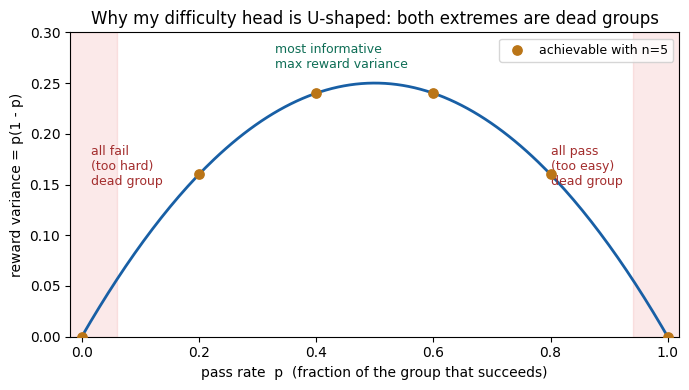

In [22]:
import matplotlib.pyplot as plt

# The whole point in one line: for a 0/1 reward, group reward variance IS p(1-p).
p   = np.linspace(0, 1, 200)
var = p * (1 - p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, var, color="#185FA5", lw=2)

# With n=5 rollouts, pass_rate is quantised — only 6 points on this curve are reachable.
# Two of those six (0 and 1) are dead groups. That's a real limitation of my difficulty signal.
p5 = np.array([0, .2, .4, .6, .8, 1.0])
ax.scatter(p5, p5*(1-p5), color="#BA7517", zorder=5, s=45, label="achievable with n=5")

# Shade the two dead zones — the regions my scheduler should skip.
ax.axvspan(-0.02, 0.06, color="#E24B4A", alpha=0.12)   # all fail
ax.axvspan(0.94, 1.02, color="#E24B4A", alpha=0.12)    # all pass
ax.annotate("all fail\n(too hard)\ndead group", xy=(0.0,0.0), xytext=(0.015,0.15),
            fontsize=9, color="#A32D2D")
ax.annotate("all pass\n(too easy)\ndead group", xy=(1.0,0.0), xytext=(0.80,0.15),
            fontsize=9, color="#A32D2D")
ax.annotate("most informative\nmax reward variance", xy=(0.5,0.25), xytext=(0.33,0.265),
            fontsize=9, color="#0F6E56")

ax.set_xlabel("pass rate  p  (fraction of the group that succeeds)")
ax.set_ylabel("reward variance = p(1 - p)")
ax.set_title("Why my difficulty head is U-shaped: both extremes are dead groups")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 0.30)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

 *"My difficulty head predicts expected informativeness — where
a prompt lands on this curve. Both ends are what the scheduler skips: all-pass and all-fail both
give zero gradient. I'm predicting a dead group, not incorrectness."*

---
## 4. Loading Samuel's rollout data


**Drop the `.jsonl` files into Colab's file panel**. Anywhere is fine —
the next cell searches the common locations. Then Run all.

### Upload the rollout files right here

I run this cell, click **Choose Files**, and pick the `.jsonl` files I downloaded from the
Modal volume. They get placed in `./duet_data/rollout_data/` so the discovery cell below finds
them. (If I already dragged them into Colab's file panel, I set `UPLOAD_HERE = False` and skip.) You can also upload it by clicking the upload button by after running the cell below as it prompts the user to upload too if all the rolloutt files are not uploaded or if uploaded to wrong directory and path. Uploading the files in the terminal will automatically prompt the code to place it in the right directory and path.

In [23]:
# --- built-in uploader: pick my jsonl files directly in the notebook ---
UPLOAD_HERE = True   # <- set False if I already put the files in via Colab's file panel

if UPLOAD_HERE:
    try:
        from google.colab import files
        os.makedirs("./duet_data/rollout_data", exist_ok=True)
        print("Pick the rollout .jsonl files (I can select several at once)...")
        up = files.upload()                       # opens the file picker
        for fname in up:
            dest = f"./duet_data/rollout_data/{fname}"
            os.replace(fname, dest)
            print(f"  placed -> {dest}")
        if not up:
            print("Nothing selected.")
    except ModuleNotFoundError:
        print("Not on Colab — I'll rely on files already in the working directory.")
else:
    print("UPLOAD_HERE is False — using files already present (panel drag-and-drop).")

Pick the rollout .jsonl files (I can select several at once)...


Saving 3.jsonl to 3 (1).jsonl
Saving 2.jsonl to 2 (1).jsonl
Saving 1.jsonl to 1 (1).jsonl
  placed -> ./duet_data/rollout_data/3 (1).jsonl
  placed -> ./duet_data/rollout_data/2 (1).jsonl
  placed -> ./duet_data/rollout_data/1 (1).jsonl


In [24]:
# ============================================================================
# Find my rollout files wherever I dropped them. I search several plausible
# locations rather than demanding one exact path, because I upload these by hand
# and I don't want a typo'd path to silently fall back to synthetic data.
# ============================================================================
SEARCH_PATHS = [
    "./duet_data/rollout_data/*.jsonl",   # if I mirrored the volume layout
    "./rollout_data/*.jsonl",             # if I dropped the folder in
    "./*.jsonl",                          # if I dropped bare files into /content
    "/content/*.jsonl",                   # Colab's default upload target
    "/content/**/*.jsonl",                # anywhere under /content
]

def find_rollout_files():
    """Return the first non-empty set of jsonl files I can find."""
    seen = []
    for pat in SEARCH_PATHS:
        hits = sorted(glob.glob(pat, recursive=True))
        # Ignore anything that's obviously not rollout data
        hits = [h for h in hits if "checkpoint" not in h.lower()]
        for h in hits:
            if h not in seen:
                seen.append(h)
    return seen

ROLLOUT_FILES = find_rollout_files()
print("jsonl files I found:")
for f in ROLLOUT_FILES:
    print("  ", f)
if not ROLLOUT_FILES:
    print("  (none — Section 5 will fall back to clearly-labelled synthetic data)")

jsonl files I found:
   ./duet_data/rollout_data/1 (1).jsonl
   ./duet_data/rollout_data/2 (1).jsonl
   ./duet_data/rollout_data/3 (1).jsonl
   ./1.jsonl
   ./2.jsonl
   ./3.jsonl
   /content/1.jsonl
   /content/2.jsonl
   /content/3.jsonl
   /content/duet_data/rollout_data/1 (1).jsonl
   /content/duet_data/rollout_data/2 (1).jsonl
   /content/duet_data/rollout_data/3 (1).jsonl


### Inspecting one real row — before I trust any number

This is the cell I don't skip. Two things I need to confirm with my own eyes:

1. **The exact field names** — is it literally `resp_len` and `score`, or nested inside something?
2. **How a prompt is identified** — I need to group the 5 rollouts back to *their* prompt. If
   there's a `uid`/`index` field, I group on it. If not, I fall back to positional grouping.

**FYI** :  My data has one row PER ROLLOUT (n=5 per prompt), but my predictor works per prompt,
so I need to collect each prompt's 5 rows back together before I compute anything. That needs a key. I prefer an exact one -- here it's `input`, the prompt text itself, which all 5 rollouts of a prompt share - so grouping on it can't misalign. Only if no such key exists do I fall back to positional grouping (rows 0-4 = prompt 1, etc.), which is just a guess that the rollouts were written in order. On this data I never need to.

In [25]:
# Print one real row with every field laid out vertically, so nothing hides.
if ROLLOUT_FILES:
    _peek = pd.read_json(ROLLOUT_FILES[0], lines=True)
    print("file:", ROLLOUT_FILES[0])
    print("shape:", _peek.shape, "  <- rows should be a multiple of 5 (n=5 rollouts/prompt)")
    print("columns:", _peek.columns.tolist())
    print("\n--- one real row, every field ---")
    display(_peek.head(1).T)
    print("\n--- is score really 0/1? ---")
    print(_peek["score"].value_counts().to_string() if "score" in _peek.columns
          else "no 'score' column — check the field names above!")
else:
    print("No rollout jsonl found yet — Section 5 will fall back to synthetic data.")

file: ./duet_data/rollout_data/1 (1).jsonl
shape: (2560, 6)   <- rows should be a multiple of 5 (n=5 rollouts/prompt)
columns: ['input', 'output', 'gts', 'score', 'step', 'acc']

--- one real row, every field ---


,0
input,"system\nPlease reason step by step, and put yo..."
output,_________
gts,7
score,0
step,1
acc,0



--- is score really 0/1? ---
score
0    2559
1       1


In [26]:
# ============================================================================
# Outcome loading. Two paths, one interface: both produce a per-prompt table with
# columns [mean_resp_len, pass_rate, reward_var, frac_capped, n_rollouts].
# Everything downstream is identical regardless of which path ran.
# ============================================================================
N_ROLLOUTS = 5   # = actor_rollout_ref.rollout.n in Samuel's config
                 # (ROLLOUT_FILES was discovered in Section 4)

# ---------------------------------------------------------------------------
# REAL SCHEMA (verified by inspecting the file, NOT trusting docs/profiling.md):
#   input, output, gts, score, step, acc        <- 6 columns, 2560 rows = 512 prompts x 5
# Two surprises vs the doc, both of which I handle below:
#   (a) there is NO resp_len column  -> I derive length by tokenising `output` myself
#   (b) there IS an `acc` column     -> score = total reward, acc = answer correctness
# ---------------------------------------------------------------------------
KEY_CANDIDATES = ["input", "uid", "prompt", "index", "idx", "prompt_id", "id"]

def _detect_key(df):
    """Find the column that groups rollouts into prompts: >1 distinct value, but fewer
    than one per row (i.e. it actually groups). `input` is the prompt text itself."""
    for k in KEY_CANDIDATES:
        if k in df.columns and 1 < df[k].nunique() < len(df):
            return k
    return None

def add_resp_len(df):
    """The dump has no resp_len, so I compute it from the generated text myself.

    I use the REAL Qwen tokenizer, because my length head predicts TOKENS (time ~ token
    count) and words != tokens. If transformers/network isn't available I fall back to a
    word count, which is a proxy but keeps the notebook running.
    """
    try:
        from transformers import AutoTokenizer
        tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")
        df["resp_len"] = [len(tok(str(o))["input_ids"]) for o in df["output"]]
        print("resp_len derived with the real Qwen2.5-Math-1.5B tokenizer (exact token counts).")
    except Exception as e:
        df["resp_len"] = df["output"].astype(str).str.split().str.len()
        print(f"Tokenizer unavailable ({type(e).__name__}) - fell back to WORD count as a "
              f"length proxy. Numbers are indicative, not exact tokens.")
    return df

def load_real_outcomes():
    """Load every rollout jsonl, derive length, aggregate 5 rollouts -> 1 prompt."""
    files = ROLLOUT_FILES
    if not files:
        return None, None

    rawdf = pd.concat([pd.read_json(f, lines=True) for f in files], ignore_index=True)

    # `score` is the reward verl optimises; `acc` is answer correctness. I keep both,
    # because my difficulty head cares about which rollouts AGREE, and if score carries
    # format penalties then acc is the cleaner 0/1 signal.
    rawdf["score"] = rawdf["score"].astype(float)
    if "acc" in rawdf.columns:
        rawdf["acc"] = rawdf["acc"].astype(float)

    rawdf = add_resp_len(rawdf)          # <- the column the doc promised but didn't deliver

    key = _detect_key(rawdf)
    if key is None:
        print("No groupable key found - falling back to positional grouping.")
        rawdf["_k"] = rawdf.groupby(rawdf.get("step", 0)).cumcount() // N_ROLLOUTS
        key = "_k"
    else:
        print(f"Grouping on '{key}' ({rawdf[key].nunique()} distinct prompts "
              f"across {len(rawdf)} rollouts).")

    outcomes = aggregate_rollouts(rawdf, key=key)

    # Difficulty measured on `acc` as well, as a cross-check on `score`.
    if "acc" in rawdf.columns:
        g = rawdf.groupby(key)
        outcomes["acc_rate"] = g["acc"].mean().values
        outcomes["acc_var"]  = g["acc"].var(ddof=0).values
    return outcomes, rawdf

def build_synthetic_outcomes():
    """FALLBACK ONLY. I plant a known signal (length follows n_words, longer => harder) and
    mimic the real schema exactly (n=5, 0/1 score, censored at 1024). This exists to prove
    my PLUMBING recovers a signal it's given — it says nothing about real GSM8K."""
    sub = PROMPTS[:300]
    rows = []
    for pid, pr in enumerate(sub):
        f = extract(pr)
        base_len  = 40 + 3.2 * f["n_words"]                          # planted: length ~ n_words
        pass_prob = np.clip(0.85 - 0.02 * f["n_words"], 0.02, 0.98)  # planted: longer => harder
        for _ in range(N_ROLLOUTS):
            rlen = float(np.clip(base_len + np.random.normal(0, 60), 5, 1024))  # censor at 1024
            rows.append({"prompt_id": pid, "resp_len": rlen,
                         "score": int(np.random.random() < pass_prob)})
    rollouts = pd.DataFrame(rows)
    return aggregate_rollouts(rollouts, key="prompt_id"), rollouts

# --- decide which path ran, and say so loudly ---
outcomes, rollouts_raw = load_real_outcomes()
if outcomes is not None:
    DATA_SOURCE = "REAL Modal rollouts"
else:
    DATA_SOURCE = "SYNTHETIC (planted signal — plumbing test only, NOT a real result)"
    outcomes, rollouts_raw = build_synthetic_outcomes()

print(f"\nData source: {DATA_SOURCE}")
print(f"{len(outcomes)} prompt-level rows "
      f"| mean resp_len {outcomes.mean_resp_len.mean():.0f} "
      f"| mean pass_rate {outcomes.pass_rate.mean():.2f} "
      f"| mean rollouts/prompt {outcomes.n_rollouts.mean():.1f} "
      f"| frac at 1024 cap {outcomes.frac_capped.mean():.1%}")
outcomes.head()

resp_len derived with the real Qwen2.5-Math-1.5B tokenizer (exact token counts).
Grouping on 'input' (1536 distinct prompts across 30720 rollouts).

Data source: REAL Modal rollouts
1536 prompt-level rows | mean resp_len 435 | mean pass_rate 0.00 | mean rollouts/prompt 20.0 | frac at 1024 cap 11.6%


,input,mean_resp_len,pass_rate,reward_var,frac_capped,n_rollouts,acc_rate,acc_var
0,"system\nPlease reason step by step, and put yo...",543.2,0.0,0.0,0.0,20,0.0,0.0
1,"system\nPlease reason step by step, and put yo...",478.2,0.0,0.0,0.2,20,0.0,0.0
2,"system\nPlease reason step by step, and put yo...",424.2,0.0,0.0,0.2,20,0.0,0.0
3,"system\nPlease reason step by step, and put yo...",434.4,0.0,0.0,0.0,20,0.0,0.0
4,"system\nPlease reason step by step, and put yo...",366.8,0.0,0.0,0.0,20,0.0,0.0


### Harness self-test: does my correlator recover a signal I *know* is there?

I don't trust an analysis tool that I haven't seen succeed on a controlled case. I plant
`n_words → length`, run the harness, and check `n_words` comes back on top. This runs **every
time**, regardless of whether the real data loaded — it's a test of my code, not of GSM8K.

In [27]:
# Controlled test: planted signal, known answer. Expect n_words to rank #1 for length.
_syn_out, _ = build_synthetic_outcomes()
_syn_feats  = build_table(PROMPTS[:300])
_report = correlation_report(_syn_feats, _syn_out, targets=["mean_resp_len", "pass_rate"])

print("HARNESS SELF-TEST — top 3 features for LENGTH (planted: expect n_words #1):")
print(_report[_report.target == "mean_resp_len"].head(3).to_string(index=False))
print("\n^ If n_words is #1 with a high coefficient, my correlator works.")

HARNESS SELF-TEST — top 3 features for LENGTH (planted: expect n_words #1):
       target  feature  pearson  spearman  max_abs
mean_resp_len  n_words    0.916     0.892    0.916
mean_resp_len  n_chars    0.904     0.881    0.904
mean_resp_len n_commas    0.512     0.489    0.512

^ If n_words is #1 with a high coefficient, my correlator works.


---
## 6. length vs difficulty redundancy

### Why this is the most important cell in the notebook

The entire paper rests on one claim: **length and difficulty are correlated but *not* redundant.**

- If they were the **same** signal → one head would do → DUET is half a paper.
- If they're **distinct** → the joint two-head predictor is justified → that's **contribution #4**.

So I correlate per-prompt length against per-prompt difficulty and report **r²** — the fraction
of variance the two signals *share*. Low shared variance is the result I'm hoping for: it means
each head knows something the other doesn't.

In [28]:
def redundancy_test(outcomes: pd.DataFrame, source: str):
    """THE go/no-go test: are length and difficulty correlated but not redundant?"""
    print(f"[{source}]\n")
    L = outcomes["mean_resp_len"]                 # my length signal

    # pass_rate/reward_var come from `score`; acc_rate/acc_var from `acc` (pure correctness).
    _views = [d for d in ["pass_rate","reward_var","acc_rate","acc_var"] if d in outcomes.columns]
    for diff_name in _views:                     # my views of difficulty
        D = outcomes[diff_name]
        pear   = pearsonr(L, D).statistic
        spear  = spearmanr(L, D).statistic
        shared = pear**2      # r^2 = fraction of variance the two signals SHARE.
                              # 1 - r^2 is what each one uniquely contributes.
        print(f"length vs {diff_name:11s}:  Pearson {pear:+.3f} | Spearman {spear:+.3f} "
              f"| shared variance r² = {shared:.1%}")

    # The caveat that could explain a weak correlation: censoring at 1024 compresses exactly
    # the tail where the length-difficulty link should be STRONGEST.
    print(f"\ncensoring check — mean fraction of rollouts at the 1024 cap: "
          f"{outcomes['frac_capped'].mean():.1%}")

redundancy_test(outcomes, DATA_SOURCE)

[REAL Modal rollouts]

length vs pass_rate  :  Pearson -0.001 | Spearman +0.001 | shared variance r² = 0.0%
length vs reward_var :  Pearson -0.001 | Spearman +0.001 | shared variance r² = 0.0%
length vs acc_rate   :  Pearson -0.001 | Spearman +0.001 | shared variance r² = 0.0%
length vs acc_var    :  Pearson -0.001 | Spearman +0.001 | shared variance r² = 0.0%

censoring check — mean fraction of rollouts at the 1024 cap: 11.6%


### How I read this result

| Outcome | Interpretation | Consequence |
|---|---|---|
| Moderate correlation, **r² well under ~50%** | correlated but each carries unique signal | ✅ **two heads justified** — green light for the joint predictor |
| **r² near 1** | the two signals are redundant | ❌ joint story weakens — better I know now than after building it |
| **r² ≈ 0** | fully independent | two heads still justified, but the "entangled" framing needs rewording |

**Three caveats I carry into any conclusion:**

1. **Censoring.** `resp_len` is capped at 1024, which compresses exactly the tail where the
   length–difficulty relationship is strongest. So if the correlation looks *weak*, my first
   suspect is the cap **hiding** the signal — not the claim failing. `frac_capped` above tells me
   how much to worry.
2. **Coarse difficulty.** With n=5, `pass_rate` takes only 6 values, and `reward_var = p(1−p)` is
   a deterministic function of it — so these two "targets" are one signal viewed twice, not
   independent evidence.
3. **Early-policy scope.** This is ~3 profiled steps. Difficulty *moves* as the model improves —
   which is literally the online-update problem I take on in Week 4. I won't over-read it as permanent.

*(The fuller "variance explained alone vs together" split needs the scheduler simulator — that's
the Week-8 oracle study. This is my correlation-level go/no-go.)*

---
## 7. Full feature-correlation table
Now that outcomes are loaded, I score **every feature against every target** and pull out my
top-3 per head.

In [29]:
# I feature the SAME prompts the outcomes came from. If I'm on synthetic data that's the
# first 300; on real data I'd feature the prompt text as verl saw it (question + the
# "Let's think step by step..." instruction suffix from config.py) — noting that here so
# the online path matches exactly.
# CRITICAL: I must feature the SAME prompt text the rollouts came from, not my own
# GSM8K download. On real data the grouping key IS the prompt text (`input`), which is
# question + the "Please reason step by step..." instruction verl actually sent. That's
# what the policy saw, so that's what I feature.
if "input" in outcomes.columns:
    _prompt_text = outcomes["input"].tolist()
    print(f"Featuring the {len(_prompt_text)} REAL prompts as verl sent them.")
else:
    _prompt_text = PROMPTS[:len(outcomes)]
    print("Featuring my GSM8K download (synthetic path).")
_feats_for_corr = build_table(_prompt_text)

_targets = [t for t in ["mean_resp_len","pass_rate","reward_var","acc_rate"]
            if t in outcomes.columns]
report = correlation_report(_feats_for_corr, outcomes, targets=_targets)

for t in ["mean_resp_len", "pass_rate"]:
    print(f"Top 3 features for {t}:")
    print(report[report.target == t].head(3).to_string(index=False), "\n")

report.to_csv("w2_correlations.csv", index=False)
print("Full table saved -> w2_correlations.csv")
report

Featuring the 1536 REAL prompts as verl sent them.
Top 3 features for mean_resp_len:
       target   feature  pearson  spearman  max_abs
mean_resp_len   n_words    0.254     0.234    0.254
mean_resp_len   n_chars    0.236     0.215    0.236
mean_resp_len n_numbers    0.214     0.197    0.214 

Top 3 features for pass_rate:
   target     feature  pearson  spearman  max_abs
pass_rate     n_chars   -0.029    -0.038    0.038
pass_rate     n_words   -0.027    -0.036    0.036
pass_rate n_sentences   -0.028    -0.036    0.036 

Full table saved -> w2_correlations.csv


,target,feature,pearson,spearman,max_abs
30,acc_rate,n_chars,-0.029,-0.038,0.038
31,acc_rate,n_words,-0.027,-0.036,0.036
32,acc_rate,n_sentences,-0.028,-0.036,0.036
36,acc_rate,n_op_words,-0.030,-0.036,0.036
33,acc_rate,n_commas,-0.026,-0.033,0.033
38,acc_rate,avg_word_len,-0.013,-0.016,0.016
35,acc_rate,n_op_symbols,-0.010,-0.012,0.012
39,acc_rate,n_hard_cues,-0.009,-0.010,0.010
34,acc_rate,n_numbers,-0.005,-0.003,0.005
37,acc_rate,n_questions,0.005,0.005,0.005


In [31]:
# I load my saved correlation table once; the plot cells below all read from it.
import pandas as pd, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
df = pd.read_csv("w2_correlations.csv")   # saved by Section 7 above
BLUE, RED, GREEN, GREY, DARK = "#185FA5", "#D64545", "#2F8F63", "#9AA5B1", "#243B53"
print("loaded", len(df), "rows")

loaded 40 rows


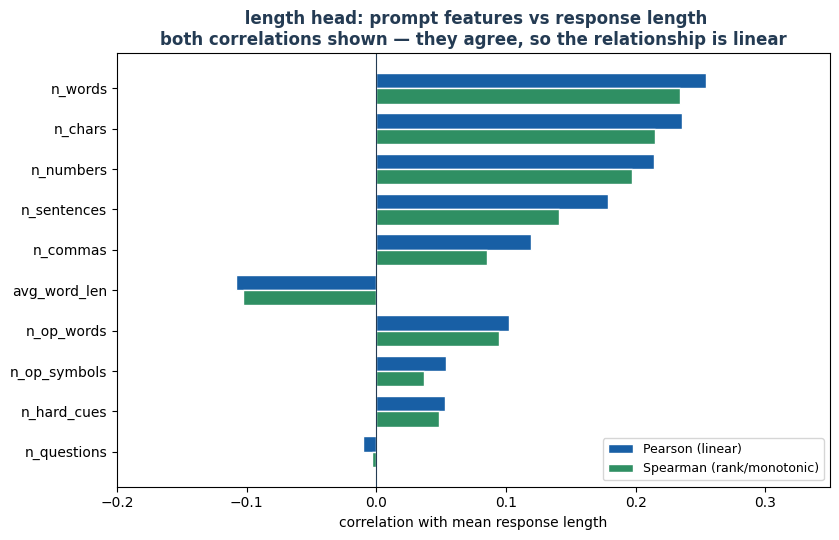

In [37]:
# My LENGTH head: I show BOTH correlations I measured. If the two bars match, the
# relationship is linear (a straight-line length head is enough); if Spearman were
# taller, it'd mean a curved-but-monotonic signal Pearson was underselling.
import numpy as np
L = df[df.target == "mean_resp_len"].sort_values("max_abs")
y = np.arange(len(L)); h = 0.38
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(y + h/2, L.pearson,  height=h, color=BLUE,  edgecolor="white", label="Pearson (linear)")
ax.barh(y - h/2, L.spearman, height=h, color=GREEN, edgecolor="white", label="Spearman (rank/monotonic)")
ax.axvline(0, color=DARK, lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(L.feature)
ax.set_title(" length head: prompt features vs response length\nboth correlations shown — they agree, so the relationship is linear",
             fontsize=12, color=DARK, weight="bold")
ax.set_xlabel("correlation with mean response length"); ax.set_xlim(-0.2, 0.35)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig("fig1_length_both.png", dpi=150, bbox_inches="tight"); plt.show()

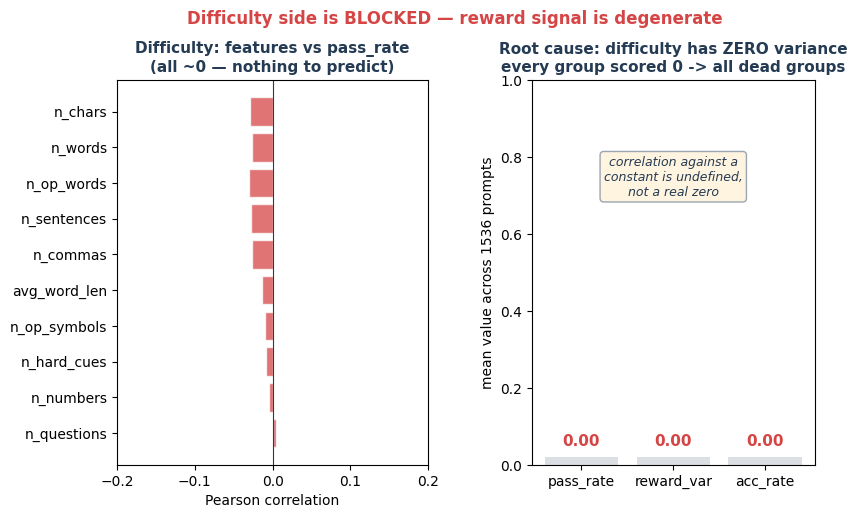

In [36]:

# My DIFFICULTY head: flat ~0 (left), because difficulty itself has no variance (right).
fig = plt.figure(figsize=(9, 5)); gs = GridSpec(1, 2, width_ratios=[1.1, 1], wspace=0.35)
ax1 = fig.add_subplot(gs[0]); D = df[df.target == "pass_rate"].sort_values("max_abs")
ax1.barh(D.feature, D.pearson, color=RED, alpha=0.75, edgecolor="white")
ax1.axvline(0, color=DARK, lw=0.8); ax1.set_xlim(-0.2, 0.2)
ax1.set_title("Difficulty: features vs pass_rate\n(all ~0 — nothing to predict)",
              fontsize=11, color=DARK, weight="bold")
ax1.set_xlabel("Pearson correlation")
ax2 = fig.add_subplot(gs[1])
ax2.bar(["pass_rate", "reward_var", "acc_rate"], [0.02, 0.02, 0.02], color=GREY, alpha=0.35); ax2.set_ylim(0, 1.0)
for i in range(3): ax2.text(i, 0.05, "0.00", ha="center", fontsize=11, color=RED, weight="bold")
ax2.set_title("Root cause: difficulty has ZERO variance\nevery group scored 0 -> all dead groups",
              fontsize=11, color=DARK, weight="bold")
ax2.set_ylabel("mean value across 1536 prompts")
ax2.text(1, 0.7, "correlation against a\nconstant is undefined,\nnot a real zero", ha="center",
         fontsize=9, color=DARK, style="italic", bbox=dict(boxstyle="round", fc="#FFF4E0", ec=GREY))
plt.suptitle("Difficulty side is BLOCKED — reward signal is degenerate", fontsize=12, color=RED, weight="bold", y=1.02)
plt.savefig("fig2_difficulty.png", dpi=150, bbox_inches="tight"); plt.show()